# Graylevel Co-Ocurrence Matrix (GLCM)

## 1.1 Cálculo da matriz GLCM

In [30]:
import collections

import matplotlib.pyplot as plt
import numpy as np


def glcm(img, shift, num_levels):
    """Calcula a matriz GLCM de uma imagem de entrada img. 
    
    O parâmetro shift indica o deslocamento utilizado para comparar os pixels. Por 
    exemplo, shift=(1,2) indica que cada pixel será relacionado com o pixel da linha
    de baixo e duas colunas para a direita. O parâmetro num_levels indica o número de 
    níveis de intensidades desejados (tamanho da matriz GLCM)"""
    
    glcm_matrix = np.zeros((num_levels, num_levels))
    
    num_rows, num_cols = img.shape
    for row in range(num_rows):
        for col in range(num_cols):
            reference_value = img[row, col]
            row_shift = row+shift[0]
            col_shift = col+shift[1]
            if row_shift>=0 and row_shift<num_rows and \
                        col_shift>=0 and col_shift<num_cols:
                neighbor_value = img[row+shift[0], col+shift[1]]
                glcm_matrix[reference_value, neighbor_value] += 1
            
    # Normaliza valores da matrix, de forma que a soma seja 1. Com isso,
    # os valores da matrix podem ser entendidos como probabilidades. Mas lembre-se
    # que os valores continuam sendo basicamente uma contagem, só que divididos por 
    # um valor constante
    glcm_matrix = glcm_matrix/np.sum(glcm_matrix)        
    
    return glcm_matrix

def glcm_numpy(img, shift, num_levels):
    """Calcula a matriz GLCM de uma imagem de entrada img utilizando funcionalidades
       da bibliotecas numpy.
       
    O parâmetro shift indica o deslocamento utilizado para comparar os pixels. Por 
    exemplo, shift=(1,2) indica que cada pixel será relacionado com o pixel da linha
    de baixo e duas colunas para a direita. O parâmetro num_levels indica o número de 
    níveis de intensidades desejados (tamanho da matriz GLCM)"""
       
    num_rows, num_cols = img.shape
    
    # Cria arrays contendo os índices de todos os pontos da imagem, e 
    # também arrays com os índices dos pontos transladados 
    rr, cc = np.meshgrid(range(num_rows), range(num_cols), indexing="ij")
    rr = rr.flatten()
    cc = cc.flatten()
    rr_shift = rr + shift[0]
    cc_shift = cc + shift[1]
    
    # Mantém apenas índices que estão dentro da imagem
    valid_indices = np.nonzero((rr_shift>=0) & (rr_shift<num_rows) \
                               & (cc_shift>0) & (cc_shift<num_cols))
    rr = rr[valid_indices]
    cc = cc[valid_indices]
    rr_shift = rr_shift[valid_indices]
    cc_shift = cc_shift[valid_indices]
    
    # Valores da imagem em cada índice
    reference_values = img[rr, cc]
    neighbor_values = img[rr_shift, cc_shift]
    
    # Conta o número de ocorrências de cada tupla (x, y), onde
    # x é o valor do pixel referência e y o valor do pixel vizinho
    counter = collections.Counter(zip(reference_values, neighbor_values))
    
    # Separa os itens do contador. keys possui as tuplas (x, y) contendo
    # os pares de níveis de intensidade e values possui a contagem
    keys, values = zip(*counter.items())
    
    glcm_matrix = np.zeros((num_levels, num_levels))
    
    # Separa as tuplas em duas listas contendo linhas e colunas
    rows, cols = zip(*keys)
    glcm_matrix[rows, cols] = values
    glcm_matrix = glcm_matrix/np.sum(glcm_matrix)
            
    return glcm_matrix

## 1.2 Testes de cálculo da matriz GLCM

In [31]:
img = np.array([[0, 1, 1, 4],
                [3, 2, 2, 1],
                [3, 2, 3, 2],
                [4, 2, 1, 1]])
glcm_mat = glcm(img, (0, 1), 5)
glcm_mat_np = glcm_numpy(img, (0, 1), 5)

print(glcm_mat)
print(glcm_mat_np)
# Imprime matriz não normalizada:
print(glcm_mat*(4*3))

[[0.         0.08333333 0.         0.         0.        ]
 [0.         0.16666667 0.         0.         0.08333333]
 [0.         0.16666667 0.08333333 0.08333333 0.        ]
 [0.         0.         0.25       0.         0.        ]
 [0.         0.         0.08333333 0.         0.        ]]
[[0.         0.08333333 0.         0.         0.        ]
 [0.         0.16666667 0.         0.         0.08333333]
 [0.         0.16666667 0.08333333 0.08333333 0.        ]
 [0.         0.         0.25       0.         0.        ]
 [0.         0.         0.08333333 0.         0.        ]]
[[0. 1. 0. 0. 0.]
 [0. 2. 0. 0. 1.]
 [0. 2. 1. 1. 0.]
 [0. 0. 3. 0. 0.]
 [0. 0. 1. 0. 0.]]


[[0.  0.  0.  ... 0.  0.  0.5]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.5 0.  0.  ... 0.  0.  0. ]]


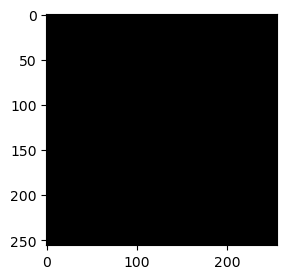

In [32]:
img = plt.imread("../../dados/textures/checkerboard.tiff")
glcm_mat = glcm(img, (0, 1), 256)
print(glcm_mat)
plt.imshow(glcm_mat, "gray")

Note que os únicos valores não nulos da matriz glcm da imagem checkerboard estão nas posições (0, 255) e (255, 0)

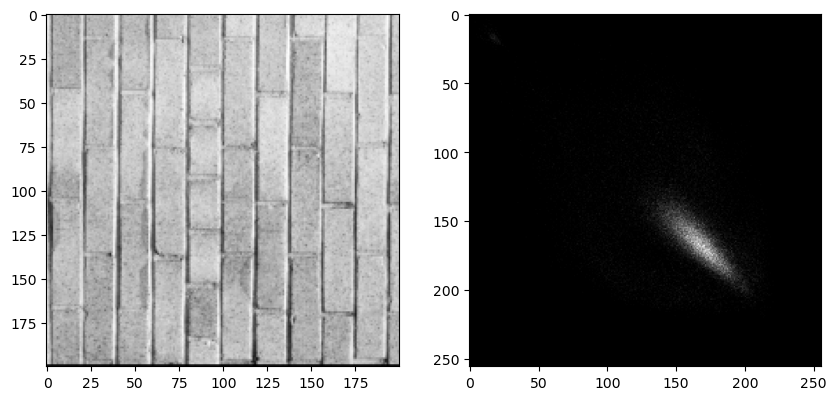

In [33]:
img = plt.imread("../../dados/textures/bricks.tiff")
glcm_bricks = glcm(img, (0, 1), 256)

plt.figure(figsize=[10,5])
plt.subplot(1, 2, 1)
plt.imshow(img, "gray")
plt.subplot(1, 2, 2)
plt.imshow(glcm_bricks, "gray")

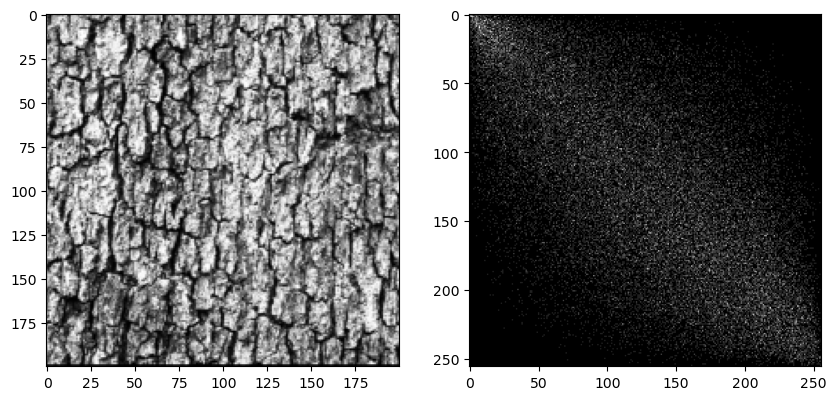

In [34]:
img = plt.imread("../../dados/textures/tree.tiff")
glcm_tree = glcm(img, (0, 1), 256)

plt.figure(figsize=[10,5])
plt.subplot(1, 2, 1)
plt.imshow(img, "gray")
plt.subplot(1, 2, 2)
plt.imshow(glcm_tree, "gray")

## 2. Cálculo de propriedades da GLCM

In [35]:
def glcm_properties(glcm_mat):
    """Calcula algumas propriedades da matriz GLCM de entrada glcm_mat"""
    
    num_rows, num_cols = glcm_mat.shape

    contrast = 0
    uniformity = 0
    homogeneity = 0
    entropy = 0
    for row in range(num_rows):
        for col in range(num_cols):
            contrast += (row-col)**2*glcm_mat[row, col]
            uniformity += glcm_mat[row, col]**2
            homogeneity += (glcm_mat[row, col]/(1+abs(row-col)))
            
            if glcm_mat[row, col]!=0:
                entropy += glcm_mat[row, col]*np.log2(glcm_mat[row, col])
    entropy *= -1
    
    return contrast, uniformity, homogeneity, entropy

props_bricks = glcm_properties(glcm_bricks)
props_tree = glcm_properties(glcm_tree)

print(f"Bricks: {props_bricks}")
print(f"Tree: {props_tree}")

Bricks: (np.float64(717.434221105528), np.float64(0.0003571071437590361), np.float64(0.17729773579214628), np.float64(12.273788325678703))
Tree: (np.float64(3040.4109296481756), np.float64(4.980303527687454e-05), np.float64(0.0695184550066899), np.float64(14.486091390241212))


#### Cálculo da matriz GLCM dada uma distância (escala) e um ângulo

In [36]:
def glcm_from_dist_and_angle(img, dist, angle, num_levels):
    """Calcula a matriz GLCM utilizando como parâmetro a distância
       ao pixel de referência e o ângulo de comparação. Esses dois
       parâmetros são utilizados para definir o deslocamente (shift)
       e chamar a função GLCM"""
    
    col = dist*np.cos(angle)
    row = -dist*np.sin(angle)
    col = int(np.round(col))
    row = int(np.round(row))
    
    shift = (row, col)
    glcm_mat = glcm(img, shift, num_levels)
    
    return glcm_mat

In [40]:
from skimage import feature

glcms = feature.graycomatrix(
    img.copy(), 
    # Distâncias utilizadas para comparar os pixels
    [2, 4, 8, 16], 
    # Ângulos utilizados para comparar os pixels
    [0, np.pi/4, np.pi/2, 3*np.pi/4], 
    # Normaliza a matriz de forma que a soma seja 1
    normed=True
    )

print(glcms.shape)

(256, 256, 4, 4)


O resultado possui 16 matrices GLCM de tamanho 256x256, cada matriz corresponde a uma combinação de distância e ângulo.

In [41]:
prop = feature.graycoprops(glcms, prop="contrast")
print(prop.shape)

(4, 4)
